In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from shapely.ops import transform
import warnings
warnings.filterwarnings('ignore')

# Ricarichiamo le stazioni NO2
stations = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\NO2 metingen locaties_geojson_latlng.json")

# Correggiamo le coordinate
stations['geometry'] = stations['geometry'].apply(
    lambda geom: transform(lambda x, y: (y, x), geom)
)
stations = stations.set_crs("EPSG:4326").to_crs("EPSG:28992")

# Ricarichiamo i dati NO2 annuali
no2 = pd.read_csv(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\NO2_JAREN.csv",
                  sep=';', encoding='latin-1')
no2.columns = [c.replace('ï»¿', '') for c in no2.columns]

# Uniamo
no2_geo = stations.merge(no2, left_on='Code', right_on='CodeJ', how='inner')
no2_geo = no2_geo[no2_geo['_2024'] > 0].copy()

print(f"Stazioni NO2 con dati 2024: {len(no2_geo)}")

Stazioni NO2 con dati 2024: 399


In [2]:
# Ricarichiamo il dataset parcheggi
parking = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\Parkeerdruk_buurten.json")

# Correggiamo le coordinate
parking['geometry'] = parking['geometry'].apply(
    lambda geom: transform(lambda x, y: (y, x), geom)
)
parking = parking.set_crs("EPSG:4326").to_crs("EPSG:28992")

# Filtriamo la fascia oraria serale feriale
parking_avond = parking[
    (parking['Dagdeel'] == 'doordeweeks avond') &
    (parking['Netto_PKD'] > 0) &
    (parking['Netto_PKD'] < 500) &
    (parking['Fout'] == 0)
].copy()

print(f"Zone parcheggio disponibili: {len(parking_avond)}")

# Join spaziale — per ogni stazione NO2 troviamo la zona parcheggio
no2_parking = gpd.sjoin_nearest(
    no2_geo[['Code', '_2024', 'geometry']],
    parking_avond[['BRT', 'Netto_PKD', 'geometry']],
    how='left'
).dropna(subset=['Netto_PKD'])

print(f"Stazioni con dati parcheggio vicini: {len(no2_parking)}")
print(f"\nCorrelazione NO2 vs Pressione Parcheggio:")
r, p = stats.pearsonr(no2_parking['_2024'], no2_parking['Netto_PKD'])
print(f"r = {r:.3f}")
print(f"p = {p:.6f}")

Zone parcheggio disponibili: 112
Stazioni con dati parcheggio vicini: 400

Correlazione NO2 vs Pressione Parcheggio:
r = 0.273
p = 0.000000


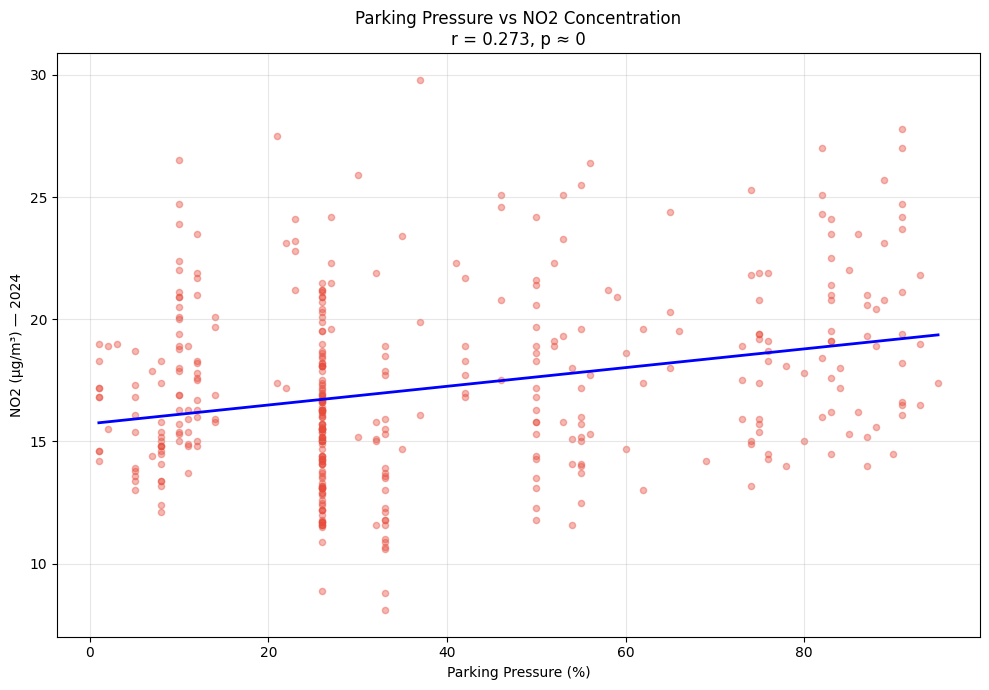

In [3]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    no2_parking['Netto_PKD'],
    no2_parking['_2024'],
    alpha=0.4,
    s=20,
    color='#e74c3c'
)

z = np.polyfit(no2_parking['Netto_PKD'], no2_parking['_2024'], 1)
x_line = np.linspace(no2_parking['Netto_PKD'].min(), no2_parking['Netto_PKD'].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), 'b-', linewidth=2)

ax.set_xlabel('Parking Pressure (%)')
ax.set_ylabel('NO2 (µg/m³) — 2024')
ax.set_title(f'Parking Pressure vs NO2 Concentration\nr = {r:.3f}, p ≈ 0', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('amsterdam_no2_parking_correlation.png', dpi=150, bbox_inches='tight')
plt.show()